# Introduction to Computational Physics: Problem Set 1
Tutorial: Chun Ming Yip (Group 3)

Document created by: Finn Zeumer

<hr>

# 0. Libaries

'Papulator' can be found under https://github.com/FinnZeumer/Papulator

By adding the _normal_ python file into the same folder as this protkect, the code will work rigth away.

In [ ]:
# Libaries
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import pandas as pd
import time
# Custom Libary from other project
import Papulator as pap
from Papulator import Sympy_Symbols as sym
from Papulator import const

## 1. Introduction
In this exercise we study a quantum particle of mass $m$ in the one-dimensional finite
square well potential
$$V(x) = \begin{cases}-V_0, & |x| < a, \\ 0, & |x| \ge a, \end{cases} \quad V_0 > 0.$$

The well has depth $V_0$ and width $2a$. We seek bound states with energy
$$-V_0 < E < 0$$

This problem is fundamental in quantum mechanics and leads to transcendental
equations that cannot be solved analytically. Therefore it is an excellent application
of numerical root finding.

## 2. Schrödinger Equation
The stationary Schrödinger equation is
$$-\frac{\hbar^2}{2m}\,\frac{d^2\psi}{dx^2}+V(x)\psi=E\psi.$$
Inside the well $(|x| < a)$, the solution is oscillatory,
$$\psi(x) = A\cos(kx) + B\sin(kx),\quad k = \sqrt{\frac{2m(E+V_0)}{\hbar^2}}.$$
Outside the well $(|x| ≥ a)$, bound states decay exponentially,
$$\psi(x) \propto e^{-\kappa |x|} , \quad \kappa = \sqrt{\frac{-2 m E}{\hbar^{2}}}.$$
Because the potential is symmetric, solutions have definite parity,
+ even states: $\psi(−x) = \psi(x)$
+ odd states: $\psi(−x) = -\psi(x)$

Matching $\psi$ and $\psi'$ at $x = a$ yields:

$$k\tan(ka)=\kappa \quad (\text{even states}) \\
-k\cot(ka)=\kappa \quad (\text{odd states}) $$

## 3. Dimensionless Form
Define
$$z = ka, \quad z_0 = a \sqrt{\frac{2mV_0}{\hbar^2}}.$$
Then
$$\kappa a = \sqrt{z_0^2 - z^2}.$$
Thus:
$$f_e(z) = z \tan(z) - \sqrt{z_0^2 - z^2} = 0 \\
f_o(z) = -z \cot(z) - \sqrt{z_0^2 - z^2} = 0 $$
with
$$0 < z < z_0.$$
Once a root $z$ is known, the energy follows from
$$E = \frac{\hbar^2 z^2}{2ma^2} - V_0.$$

<hr>

## Excersice 1: Insept the Functions
Use units
$$\hbar = 1, \quad m = 1, \quad a = 1.$$
Use $V_0 = 20$.
1. Inspect the function by plotting even and odd components for bound states.
Note characteristic features of the functions and discuss them. Make sure the
plot does not contain misleading lines! (1 pt.)
2. Write information output about the problem setup. For a given $V_0$ your code
should tell the user how many roots (approximately) will be expected. Also,
your code should esimate whether the roots are likely to be of multiplicity 1
(simple root). (1 pt.)

z0 = 6.32
Expected bound states: \approx 3


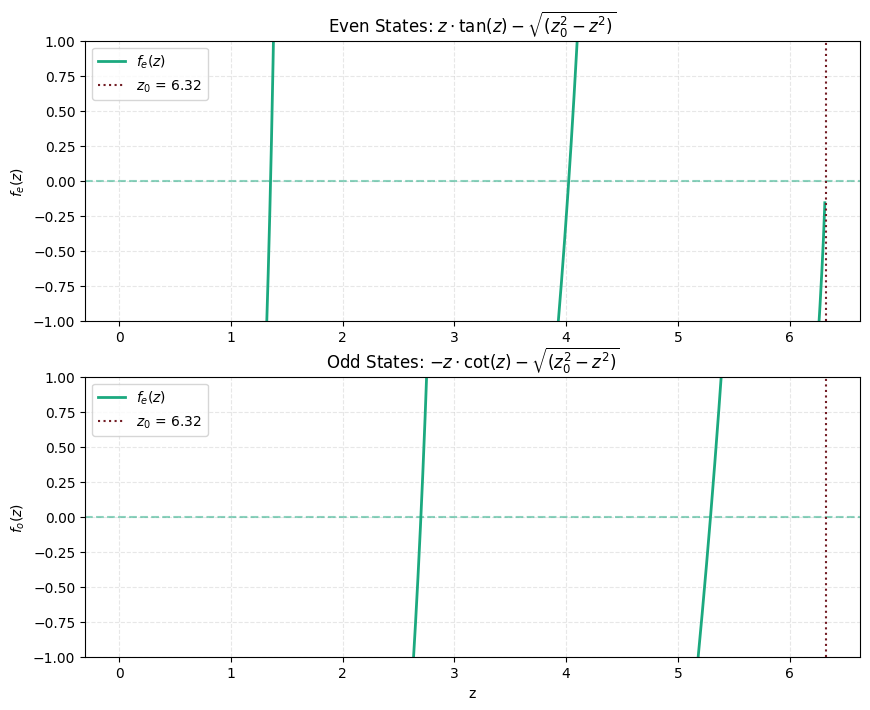

<Axes: title={'center': 'Odd States: $-z \\cdot \\cot(z) - \\sqrt{(z_0^2 - z^2)}$'}, xlabel='z', ylabel='$f_o(z)$'>

In [58]:
#   Excersice 1: PLOTTING
# ====================================================================================

# Parameters/Konstants
h_bar = 1
m = 1
a = 1
V_0 = 20

# Calculate z_0
z_0 = a * np.sqrt(2 * m * V_0 / h_bar**2)
print(f"z0 = {z_0:.2f}")
# print(z_0/np.pi + 1)
print(fr"Expected bound states: \approx {int(z_0/np.pi) + 1}")

# Define the functions 
def f_even(z_val):
    return z_val * np.tan(z_val) - np.sqrt(z_0**2 - z_val**2)

def f_odd(z_val):
    return -z_val / np.tan(z_val) - np.sqrt(z_0**2 - z_val**2)

# Create z array, avoiding singularities at z = pi/2, pi, 3pi/2, ... (halfe Multiples of pi)
z_val = np.linspace(0.01, z_0 - 0.01, 10000)

# Handle singularities by masking
mask_even = np.abs(np.cos(z_val)) > 0.01  # tan(z) goes to infty when cos(z) \approx 0
mask_odd = np.abs(np.sin(z_val)) > 0.01   # cot(z) goes to infty when sin(z) \approx 0

# Plot
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Cutting the function, thus the vertical liens disapeare
f_even_fixed = np.where(mask_even, f_even(z_val), np.nan)

ax[0].plot(
    z_val,
    f_even_fixed, 
    linewidth=2, 
    label='$f_e(z)$'
    )


# Line at 0
ax[0].axhline(y=0, linestyle='--', alpha=0.5)

# Line marking z_0
ax[0].axvline(x=z_0, linestyle=':', label=f'$z_0$ = {z_0:.2f}', color=pap.Colors.WINE_RED)

ax[0].set_ylabel('$f_e(z)$')
ax[0].set_title(r'Even States: $z \cdot \tan(z) - \sqrt{(z_0^2 - z^2)}$')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Cutting the function, thus the vertical liens disapeare
f_odd_fixed = np.where(mask_odd, f_odd(z_val), np.nan)

ax[1].plot(
    z_val,
    f_odd_fixed, 
    linewidth=2, 
    label='$f_e(z)$'
    )

ax[1].axhline(y=0, linestyle='--', alpha=0.5)
ax[1].axvline(x=z_0, linestyle=':', label=fr'$z_0$ = {z_0:.2f}', color=pap.Colors.WINE_RED)
ax[1].set_xlabel('z')
ax[1].set_ylabel('$f_o(z)$')
ax[1].set_title(r'Odd States: $-z \cdot \cot(z) - \sqrt{(z_0^2 - z^2)}$')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# # Fokus on Roots (visualising vertical lines that should be abolished)
ax[0].set_ylim(-1,1)
ax[1].set_ylim(-1,1)
# ax[1].set_xlim(2,3)

pap.plot_me()

Looking at the roots we see that all roots should be of multiplicity 1, since the function is somoot between the singulrities (peaks of tan/cotan), the slop at (around) the root point is $\not = 0$ and around the corssings there is no degenerate distribution (the function is continuous around the roots.)

<hr>

In [35]:
# Helper functions
def estimateIntervall(val:float, abw:float=10):
    '''
    Gets an estimated root and a percentage value to get quicker the intervall

    Params
    -----
        val : estimated root position
        abw : percentage of how big the intervall should be around val
    '''
    diff = val * abw / 100
    return val - diff, val + diff

def calc_z_0(V_0:int = 20):
    return a * np.sqrt(2 * m * V_0 / h_bar**2)

In [36]:
# Defining functions in sympy
z_0 = calc_z_0(20)
z = sp.symbols('z')

func_even = z * sp.tan(z) - sp.sqrt(z_0**2 - z**2)
func_odd = -z / sp.tan(z) - sp.sqrt(z_0**2 - z**2)

## Exercise 2: Root Finding
Implement the following methods: (5 pt.)
+ bisection
+ Newton method
+ secant method

Use all of them to compute one selected root. For each method measure and comment
on (3 pt.)
+ number of iterations
+ runtime
+ final residual

In [ ]:
def root_bi_section(function:sp, a:float, b:float, data = None, tolerance: float = 1e-4, max_iterations:int = 5000):
    '''
    Method to find the root of a given Functin between a given intervall [a,b].

    Params
    -----
        func : function to be analysed (sympy). Must be one dimensionl (one parameter!)
        params : Parameter of the function
            must be phrased as an array
        data : Values for the parameters
            must be phrased as an array
        a : smaller (left) limit of intervall
        b : bigger (right) limit of intervall
        tolarance : How cloase the result should get
        max_iterations : exit crit 

    Returns
    ----
        p : approximated position of root
        log : information of the algorithm (iterations, searching intervall of current, p of current iteration, f(p) of current iteration, error of current iteration, time of the current iteration and totoal time until current iteration)
        total_time : time needed to approximate root

    Raises
    ----
        ValueError : If the function does not depend on exactly one free symbol.
        RuntimeError : If the function deos not converges to an value within the while loop (given iterations)
    '''
    # Check number of free symbols
    free_vars = function.free_symbols
    if len(free_vars) != 1:
        raise ValueError(f"The function must depend on exactly one variable. Found {len(free_vars)}: {free_vars}")
    
    # Get the single variable
    var = list(free_vars)[0]  

    # Lambdify functions
    f = sp.lambdify(var, function, "numpy")

    # Calcualate initial values 
    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        raise ValueError('The initial contition that f(a) times f(b) > 0  is not satisfied')
        # return None, None, None

    # Saving information of every Iteration 
    log = {
        'iteration': [],
        'a': [],
        'b': [],
        'p': [],
        'f_p': [],
        'error': [],
        'time_step': [], # Time for one iteration
        'cumulative_time': [0.0] # total time
    }

    start_total_time = time.perf_counter()
    cumulative_time = 0.0

    # define recursive function to get closer and closer to the root
    i = 0
    while i < max_iterations:
        iter_start = time.perf_counter()
        # calculate the arethmetic mean of a and b and its value
        p = (a+b)/2
        fp = f(p)

        # Calculate error (width of the interval)
        error = (b - a) / 2


        # Store current iteration data
        log['iteration'].append(i)
        log['a'].append(a)
        log['b'].append(b)
        log['p'].append(p)
        log['f_p'].append(fp)
        log['error'].append(error)

        if abs(fp) < tolerance or (b-a)/2 < tolerance:
            return p, log, total_time

        # check if either a or b must turn p
        if fa * fp < 0:
            b = p
            fb = fp
        else:
            a = p
            fa = fp

        i = i + 1
        
        iter_end = time.perf_counter()
        step_duration = iter_end - iter_start
        cumulative_time += step_duration

        # Time logging
        log['time_step'].append(step_duration)
        log['cumulative_time'].append(cumulative_time)

        total_time = time.perf_counter() - start_total_time

    raise RuntimeError("Bisection method did not converge within the maximum number of iterations.")


In [ ]:
def root_by_newt(func:sp, p_0:float, tolerance:float = 1e-4, max_iterations:int = 1000):
    '''
    Approximate a root using the Newton-Raphson Method.
    
    Params
    ------
        func : A SymPy expression representing a function of one variable.
        p_0 : Initial guess.
        tolerance : Convergence tolerance.
        max_iterations : Maximum number of iterations.
        
    Returns
    ------
        p : approximatd root abscissa (x-Value)
        log : information of the algorithm (iterations, searching intervall of current, p of current iteration, f(p) of current iteration, error of current iteration, time of the current iteration and totoal time until current iteration)
        total_time : time needed to approximate root

    Raises
    ------
        ValueError : If the function does not depend on exactly one free symbol.
        RuntimeError : If the function deos not converges to an value within the while loop (given iterations)
    '''
    # Check number of free symbols
    free_vars = func.free_symbols
    if len(free_vars) != 1:
        raise ValueError(f"The function must depend on exactly one variable. Found {len(free_vars)}: {free_vars}")
    
    # Get the single variable
    var = list(free_vars)[0]  
    
    # Compute derivative
    func_prime = sp.diff(func, var)
        
    # Saving information of every Iteration 
    log = {
        'iteration': [],
        'p': [],
        'f_p': [],
        'f_prime_p': [], # Value of f'(p)
        'error': [],
        'time_step': [], # Time for one iteration
        'cumulative_time': [] # total time
    }

    start_total_time = time.perf_counter()
    cumulative_time = 0.0

    # Newton-Raphson iteration
    p = p_0
    i = 0
    while i < max_iterations:
        iter_start = time.perf_counter()
        f_p_val = func.subs(var, p)
        fp_p_val = func_prime.subs(var, p)
        
        if fp_p_val == 0:
            raise ZeroDivisionError("Derivative is zero; Newton's method fails.")
        
        p_new = p - f_p_val / fp_p_val
        if abs(p_new - p) < tolerance:
            return float(p_new), log, total_time
        
        error = abs(p_new - p)

        # Add information in log
        log['iteration'].append(i)
        log['p'].append(p_new)
        log['f_p'].append(f_p_val)
        log['f_prime_p'].append(fp_p_val)
        log['error'].append(error)

        p = p_new
        i = i + 1

        iter_end = time.perf_counter()
        step_duration = iter_end - iter_start
        cumulative_time += step_duration

        log['time_step'].append(step_duration)
        log['cumulative_time'].append(cumulative_time)

        total_time = time.perf_counter() - start_total_time

    raise RuntimeError("Newton's method did not converge within the maximum number of iterations.")

In [39]:
def root_by_secant(func:sp, x_0:float, x_1:float, tolerance:float = 1e-12, max_iterations:int = 1000):
    '''
    Method to approximate the root of an given function by using the secant method.

    Params
    ------
        func : A SymPy expression representing a function of one variable.
        x_0 : first point for secant
        x_1 : second point for secant
        tolerance : Convergence tolerance.
        max_iterations : Maximum number of iterations.

    Returns
    ------
        p : approximatd root abscissa (x-Value)
        log : information of the algorithm (iterations, searching intervall of current, p of current iteration, f(p) of current iteration, error of current iteration, time of the current iteration and totoal time until current iteration)
        total_time : time needed to approximate root

    Raises
    ------
        ValueError : If the function does not depend on exactly one free symbol.
        RuntimeError : If the function deos not converges to an value within the while loop (given iterations)
    '''

    # Check number of free symbols
    free_vars = func.free_symbols
    if len(free_vars) != 1:
        raise ValueError(f"The function must depend on exactly one variable. Found {len(free_vars)}: {free_vars}")
    
    # Get the single variable
    var = list(free_vars)[0]  

    # Lambdify functions
    f = sp.lambdify(var, func, "numpy")

    # Saving information of every Iteration 
    log = {
        'iteration': [],
        'p': [],
        'x_0': [],
        'x_1': [],
        'error': [],
        'time_step': [], # Time for one iteration
        'cumulative_time': [0.0] # total time
    }

    start_total_time = time.perf_counter()
    cumulative_time = 0.0

    # Starting conditions
    x_n0 = x_0 
    x_n1 = x_1


    i = 0
    # Starting the iteration
    while i < max_iterations:
        iter_start = time.perf_counter()

        # Calculation new x value 
        new_x = x_n1 - f(x_n1) * (x_n1 - x_n0)/(f(x_n1) - f(x_n0))

        error = np.abs(x_n0 - x_n1) / 2

        # Log information
        log['iteration'].append(i)
        log['p'].append(new_x)
        log['x_0'].append(x_n0)
        log['x_1'].append(x_n1)
        log['error'].append(error)

        # Set new conditions
        x_n0 = x_n1
        x_n1 = new_x

        if abs(x_n0 - x_n1) < tolerance:
            return x_n1, log, total_time
        
        i = i + 1

        iter_end = time.perf_counter()
        step_duration = iter_end - iter_start
        cumulative_time += step_duration

        # Logging times
        log['time_step'].append(step_duration)
        log['cumulative_time'].append(cumulative_time)

        total_time = time.perf_counter() - start_total_time

    raise RuntimeError("Bisection method did not converge within the maximum number of iterations.")

### Example of bisection

In [40]:
intervall = estimateIntervall(1.35, 10)

a = intervall[0]
b = intervall[1]
tol = 1e-15 # Why does it brak after e-15  -> Single Float limit

print(f'Intervall is set to: I = [{intervall[0]:.4f}, {intervall[1]:.4f}]')
root_e, log_e, timer_e = root_bi_section(func_even, a, b)

print(f'The root is (approximately) at: x = {root_e:.5f}')
print(f'Iterationen: {len(log_e['iteration'])}\nCalculation Time: {timer_e:.3g}s')

print('=========================')

intervall = estimateIntervall(2.7, 10)

a = intervall[0]
b = intervall[1]
tol = 1e-15

print(f'Intervall is set to: I = [{intervall[0]:.4f}, {intervall[1]:.4f}]')
root, log, timer = root_bi_section(func_odd, a, b)

print(f'The root is (approximately) at: x = {root:.5f}')
print(f'Iterationen: {len(log['iteration'])}\nCalculation Time: {timer:.3g}s')

Intervall is set to: I = [1.2150, 1.4850]
The root is (approximately) at: x = 1.35494
Iterationen: 12
Calculation Time: 0.000181s
Intervall is set to: I = [2.4300, 2.9700]
The root is (approximately) at: x = 2.70046
Iterationen: 13
Calculation Time: 0.000186s


/tmp/ipykernel_13137/2173131419.py:18: RuntimeWarning: invalid value encountered in sqrt
  return z_val * np.tan(z_val) - np.sqrt(z_0**2 - z_val**2)


(1.3413944091796877, 1.3684932861328125)

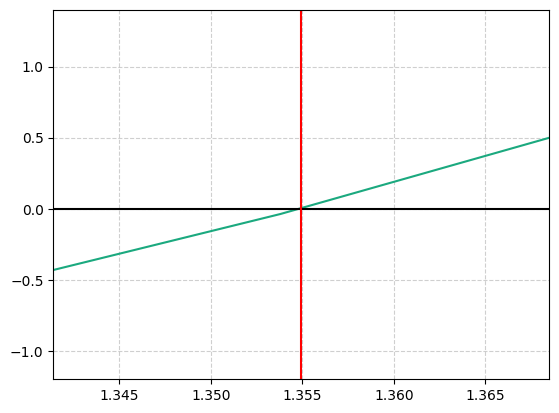

In [41]:
p = np.linspace(0, calc_z_0(20), 1000)
plt.plot(p, f_even(p))
plt.hlines(0, 0, z_0, 'black')
plt.vlines(root_e, 10, -10, 'red')
plt.ylim(-1.2,1.4)
lo = estimateIntervall(root_e, 1)
plt.xlim(lo[0], lo[1])
# plt.xlim(1,2)


Question: Why do my computers get different results for the root.

### Example of Newton method

In [42]:
print(fr'For the even function we search for a root')
root, log, timer = root_by_newt(func_even, 1.35) 
print(fr'Root found at {root:.4f}')
print(fr'with a totoal of {len(log['iteration'])} iterations')
print(fr'and a calculation time of {timer:.3g}s')

print('=========================')

print(fr'For the odd function we search for a root')
root, log, timer = root_by_newt(func_odd, 2.7) 
print(fr'Root found at {root:.4f}')
print(fr'with a totoal of {len(log['iteration'])} iterations')
print(fr'and a calculation time of {timer:.3g}s')

For the even function we search for a root
Root found at 1.3549
with a totoal of 2 iterations
and a calculation time of 0.0321s
For the odd function we search for a root
Root found at 2.7004
with a totoal of 1 iterations
and a calculation time of 0.0117s


## Example of Secant

In [43]:
intervall = estimateIntervall(1.35, 10)
print(fr'For the even function we search for a root in I = [{intervall[0], intervall[1]}]')
root, log, timer = root_by_secant(func_even, intervall[0], intervall[1])
print(fr'Root found at {root:.4f}')
print(fr'with a totoal of {len(log['iteration'])} iterations')
print(fr'and a calculation time of {timer:.3g}s')

print('=========================')

intervall = estimateIntervall(2.7, 0.0001)
print(fr'For the even function we search for a rood in I = [{intervall[0], intervall[1]}]')
root_odd, log, timer = root_by_secant(func_odd, intervall[0], intervall[1])
print(fr'root found at {root_odd:.4f}')
print(fr'with a totoal of {len(log['iteration'])} iterations')
print(fr'and a calculation time of {timer:.3g}s')

For the even function we search for a root in I = [(1.215, 1.485)]
Root found at 1.3549
with a totoal of 9 iterations
and a calculation time of 0.000323s
For the even function we search for a rood in I = [(2.6999973, 2.7000027)]
root found at 2.7004
with a totoal of 4 iterations
and a calculation time of 0.00011s


<hr>

## Exercise 3: Automatic Detection of All Roots (7 pt.)
Construct an automated algorithm that finds all roots of $f_e(z) = 0$ and $f_o(z) = 0$ in
the interval $0 < z < z_0$. Split the interval in a clever way. Compute all bound-state
energies. Why is the parity-separated formulation numerically useful?

In [44]:
def calc_multiplcity(func:sp, root:float, tolerance:float=1e-4, safety_limit:int=100):
    '''
    Calculates the multiplicity of a root of a given one-dimensional function.

    Params
    -----------
    func : sympy expression
        The one dimensional function to analyze
    root_val : float or sympy number
        The specific root value to check
    tol : float
        Tolerance for zero comparison
    safety_limit : int 
        maximum possible multiplicity of function
    
    Returns
    --------
    int : Multiplicity of the root, or None if not a root
    '''
    
    # Check number of free symbols
    free_vars = func.free_symbols
    if len(free_vars) != 1:
        raise ValueError(f"The function must depend on exactly one variable. Found {len(free_vars)}: {free_vars}")
    
    # Get the single variable
    var = list(free_vars)[0] 
    
    # Check if given root is actually a root
    if np.abs(func.subs(var, root)) > tolerance:
        return None

    derivative = func
    multiplcity = 0
    while True:
        # Calculate value of derivertive of root value
        d_root_val = derivative.subs(var, root)
        
        if np.abs(d_root_val) > tol:
            return multiplcity

        multiplcity = multiplcity + 1
        derivative = sp.diff(derivative, var)

        if multiplcity == safety_limit:
            raise ValueError("Maximum multiplicity exceeded.")    

In [45]:
def find_root_intervalls(func:sp, intervall_start:float, intervall_end:float, division_size:float=0.25, critical_value:float=5, tolerance:float=1e-4):
    '''
    Estimates intervalls where root are very likely to be, by checking sign changes all over the plot. Also tries to estimate possible local extrama (multiplicity of > 0).

    Params
    -----------
    func : sympy expression
        The one dimensional function to analyze
    intervall_start : float
        Start of the intervall to check for roots
    intervall_end : float
        End of the intervall to check for roots
    division_size : float
        How big the steps should be to check for sign changes.
    critical_value : float
        Only sign changes where the function values are smaller than this value are considered as root intervalls. This is to avoid intervalls where the function just changes its sign but does not get close to zero (e.g. at singularities).

    Retunrs
    -----------
    sing_change_intervall : List of estimated intervalls where roots are likely to be. Each tuple contains the start and end of the intervall.
    possible_mulitplicity_root : List of estimated intervall where roots might just be of higher multiplicity.
    '''

    # Check number of free symbols
    free_vars = func.free_symbols
    if len(free_vars) != 1:
        raise ValueError(f"The function must depend on exactly one variable. Found {len(free_vars)}: {free_vars}")
    
    # Get the single variable
    var = list(free_vars)[0] 

    x_values = np.arange(intervall_start, intervall_end, division_size)
    # f_values = np.array([func.subs(var, x) for x in x_values], dtype=np.float64)

    # Cehck for complex numbers (error)
    f_values = []
    for x in x_values:
        val = func.subs(var, x)
        val = complex(val)  # force numeric evaluation
        
        if np.isfinite(val.real) and abs(val.imag) < 1e-12:
            f_values.append(val.real)
        else:
            f_values.append(np.nan)  # mark invalid points

    f_values = np.array(f_values)

    sing_change_intervall = []
    possible_mulitplicity_root = []
    # Estimating by looking for sign changes
    for p in range(len(f_values) - 1):
        if np.isnan(f_values[p]) or np.isnan(f_values[p+1]):
            continue
        if (f_values[p] * f_values[p+1] < 0) and (np.abs(f_values[p]) < critical_value or np.abs(f_values[p+1]) < critical_value):
            # print(f'found sign change between\n f({x_values[p]:.2f})={f_values[p]} and\n f({x_values[p+1]:.2f})={f_values[p+1]}\n and all absolut function values are smaller than {critical_value}')
            sing_change_intervall.append((x_values[p], x_values[p+1]))
        elif np.abs(f_values[p]) * np.abs(f_values[p+1]) < tolerance:
            possible_mulitplicity_root.append((x_values[p], x_values[p+1]))

    return sing_change_intervall, possible_mulitplicity_root

In [46]:
def calc_roots(func:sp, intervall_start:float, intervall_end:float, division_size:float=0.25, critical_value:float=5, tolerance:float=1e-4, max_iterations:int = 1000):
    '''
    Approximates roots of a given one dimensional function.

    Params
    -----------
    func : sympy expression
        The one dimensional function to analyze
    intervall_start : float
        Start of the intervall to check for roots
    intervall_end : float
        End of the intervall to check for roots
    division_size : float
        How big the steps should be to check for sign changes.
    critical_value : float
        Only sign changes where the function values are smaller than this value are considered as root intervalls. This is to avoid intervalls where the function just changes its sign but does not get close to zero (e.g. at singularities).

    Retunrs
    -----------
    roots : List of approximated roots, iterations and runtimes
        1. Secant
        2. Newton
        3. Bisection
    '''

    root_intervalls = find_root_intervalls(func, intervall_start, intervall_end, division_size, critical_value, tolerance)

    roots_secant = []
    iterations_secant = []
    runtime_secant = []
    for i, val in enumerate(root_intervalls):
        r = root_by_secant(func, root_intervalls[0][i][0], root_intervalls[0][i][1], tolerance=tolerance, max_iterations=max_iterations)
        roots_secant.append(r[0])
        iterations_secant.append(len(r[1]['iteration']))
        runtime_secant.append(r[2])

    roots_newton = []
    iterations_newton = []
    runtime_newton = []
    for i, val in enumerate(root_intervalls):
        r = root_by_newt(func, np.mean(root_intervalls[0][i]), tolerance=tolerance, max_iterations=max_iterations)
        roots_newton.append(r[0])
        iterations_newton.append(len(r[1]['iteration']))
        runtime_newton.append(r[2])

    roots_bisection = []
    iterations_bisection = []
    runtime_bisection = []
    for i, val in enumerate(root_intervalls):
        r = root_bi_section(func, root_intervalls[0][i][0], root_intervalls[0][i][1], tolerance=tolerance, max_iterations=max_iterations)
        roots_bisection.append(r[0])
        iterations_bisection.append(len(r[1]['iteration']))
        runtime_bisection.append(r[2])

    
    return [roots_secant, roots_newton, roots_bisection], [iterations_secant, iterations_newton, iterations_bisection], [runtime_secant, runtime_newton, runtime_bisection]

<hr>

## Exercise 4: Speed vs Accuracy (3 pt.)
For one root compare the methods for tolerances
$$10^{−4}, 10^{−8}, 10^{−12}.$$
Create:
+ a table of iterations and runtime
+ a plot of runtime vs residual
+ a short discussion

In [47]:
tol = [1e-4, 1e-8, 1e-12]

iterations = []
runtimes = []
roots = []

# Calculating roots for odd function
for t in tol:
    r = calc_roots(func_odd, 0, z_0, 0.05, tolerance=t)
    roots.append(r[0])
    iterations.append(r[1])
    runtimes.append(r[2])

# Printing the results in a structerd form
print('Secant Method:')
for i in range(len(tol)):
    print(f'{tol[i]}:')
    print('--------')
    print(roots[0][i])
    print(iterations[0][i])
    print(f'{np.mean(runtimes[0][i]):.3g}s')

print('\n=========================\n')

print('Newton Method:')
for i in range(len(tol)):
    print(f'{tol[i]}:')
    print('--------')
    print(roots[1][i])
    print(iterations[1][i])
    print(f'{np.mean(runtimes[1][i]):.3g}s')
    
print('\n=========================\n')

print('Bisection Method:')
for i in range(len(tol)):
    print(f'{tol[i]}:')
    print('--------')
    print(roots[2][i])
    print(iterations[2][i])
    print(f'{np.mean(runtimes[2][i]):.3g}s')


Secant Method:
0.0001:
--------
[np.float64(2.7004397124828285), np.float64(5.291910861788999)]
[2, 3]
6.46e-05s
1e-08:
--------
[2.7004446997817735, 5.291910861564826]
[2, 2]
0.0196s
1e-12:
--------
[np.float64(2.70048828125), np.float64(5.291894531250001)]
[9, 9]
0.000125s


Newton Method:
0.0001:
--------
[np.float64(2.7004446997553613), np.float64(5.291910861564825)]
[4, 4]
8.76e-05s
1e-08:
--------
[2.7004446997553666, 5.291910861564826]
[3, 3]
0.0117s
1e-12:
--------
[np.float64(2.7004447042942044), np.float64(5.291910856962206)]
[23, 23]
0.00019s


Bisection Method:
0.0001:
--------
[np.float64(2.7004446997553666), np.float64(5.291910861564825)]
[5, 5]
0.000104s
1e-08:
--------
[2.7004446997553666, 5.291910861564826]
[4, 3]
0.0119s
1e-12:
--------
[np.float64(2.7004446997547342), np.float64(5.291910861564248)]
[36, 36]
0.000283s


In [48]:
# AI-Generated for faster generation of tables
def generate_root_table(results, func_name="Function"):
    """
    Generates a Markdown table from the output of calc_roots.
    
    Args:
        results: Tuple of (roots_list, iterations_list, runtimes_list)
                 where each inner list corresponds to [Secant, Newton, Bisection]
        func_name: Name of the function being tested
    
    Returns:
        String containing the Markdown table
    """
    roots_list, iters_list, times_list = results
    
    # Extract the three method lists
    secant_roots, newton_roots, bisection_roots = roots_list
    secant_iters, newton_iters, bisection_iters = iters_list
    secant_times, newton_times, bisection_times = times_list
    
    # Determine the number of roots found (assuming all methods found the same count)
    num_roots = len(secant_roots)
    
    if num_roots == 0:
        return f"No roots found for {func_name}."

    # Build Header
    md = f"### Results for: {func_name}\n\n"
    md += "| Root #     |       | Secant Root   | Secant Iters  | Secant Time   |       | Newton Root   | Newton Iters  | Newton Time   |       | Bisection Root    | Bisection Iters   | Bisection Time    |\n"
    md += "| :---:      |:---:  | :---:         | :---:         | :---:         |:---:  | :---:         | :---:         | :---:         |:---:  | :---:             | :---:             | :---:             |\n"
    
    # Build Rows
    for i in range(num_roots):
        # Format values safely (handle potential empty lists if a method failed)
        s_r = f"{secant_roots[i]:.6g}" if i < len(secant_roots) else "-"
        s_i = str(secant_iters[i]) if i < len(secant_iters) else "-"
        s_t = f"{secant_times[i]:.3g}s" if i < len(secant_times) else "-"
        
        n_r = f"{newton_roots[i]:.6g}" if i < len(newton_roots) else "-"
        n_i = str(newton_iters[i]) if i < len(newton_iters) else "-"
        n_t = f"{newton_times[i]:.3g}s" if i < len(newton_times) else "-"
        
        b_r = f"{bisection_roots[i]:.6g}" if i < len(bisection_roots) else "-"
        b_i = str(bisection_iters[i]) if i < len(bisection_iters) else "-"
        b_t = f"{bisection_times[i]:.3g}s" if i < len(bisection_times) else "-"
        
        md += f"| {i+1} || {s_r} | {s_i} | {s_t} || {n_r} | {n_i} | {n_t} || {b_r} | {b_i} | {b_t} |\n"
    
    return md

In [49]:
tol = [1e-4, 1e-8, 1e-12]

print('## Really Ugly Tables:')
for t in tol:
    results = calc_roots(func_odd, 0, z_0, 0.05, tolerance=t)

    table_md = generate_root_table(results, func_name=fr'$f_\text{{odd}}$ with tolerance={t:.0e}')

    print(table_md)

print('<hr>' * 2, '\n')

for t in tol:
    results = calc_roots(func_even, 0, z_0, 0.05, tolerance=t)

    table_md = generate_root_table(results, func_name=fr'$f_\text{{even}}$ with tolerance={t:.0e}')

    print(table_md)

## Really Ugly Tables:
### Results for: $f_\text{odd}$ with tolerance=1e-04

| Root #     |       | Secant Root   | Secant Iters  | Secant Time   |       | Newton Root   | Newton Iters  | Newton Time   |       | Bisection Root    | Bisection Iters   | Bisection Time    |
| :---:      |:---:  | :---:         | :---:         | :---:         |:---:  | :---:         | :---:         | :---:         |:---:  | :---:             | :---:             | :---:             |
| 1 || 2.70044 | 2 | 5.99e-05s || 2.70044 | 2 | 0.00736s || 2.70049 | 9 | 8.08e-05s |
| 2 || 5.29191 | 3 | 6.69e-05s || 5.29191 | 2 | 0.00689s || 5.29189 | 9 | 7.68e-05s |

### Results for: $f_\text{odd}$ with tolerance=1e-08

| Root #     |       | Secant Root   | Secant Iters  | Secant Time   |       | Newton Root   | Newton Iters  | Newton Time   |       | Bisection Root    | Bisection Iters   | Bisection Time    |
| :---:      |:---:  | :---:         | :---:         | :---:         |:---:  | :---:         | :---:         | 

## Really Ugly Tables:
### Results for: $f_\text{odd}$ with tolerance=1e-04
| Root #     |       | Secant Root   | Secant Iters  | Secant Time   |       | Newton Root   | Newton Iters  | Newton Time   |       | Bisection Root    | Bisection Iters   | Bisection Time    |
| :---:      |:---:  | :---:         | :---:         | :---:         |:---:  | :---:         | :---:         | :---:         |:---:  | :---:             | :---:             | :---:             |
| 1 || 2.70044 | 2 | 2.27e-05s || 2.70044 | 2 | 0.00479s || 2.70049 | 9 | 4.62e-05s |
| 2 || 5.29191 | 3 | 3.53e-05s || 5.29191 | 2 | 0.00459s || 5.29189 | 9 | 6.38e-05s |

### Results for: $f_\text{odd}$ with tolerance=1e-08

| Root #     |       | Secant Root   | Secant Iters  | Secant Time   |       | Newton Root   | Newton Iters  | Newton Time   |       | Bisection Root    | Bisection Iters   | Bisection Time    |
| :---:      |:---:  | :---:         | :---:         | :---:         |:---:  | :---:         | :---:         | :---:         |:---:  | :---:             | :---:             | :---:             |
| 1 || 2.70044 | 4 | 6.03e-05s || 2.70044 | 3 | 0.00347s || 2.70044 | 23 | 0.000132s |
| 2 || 5.29191 | 4 | 4.58e-05s || 5.29191 | 3 | 0.00339s || 5.29191 | 23 | 0.000131s |

### Results for: $f_\text{odd}$ with tolerance=1e-12

| Root #     |       | Secant Root   | Secant Iters  | Secant Time   |       | Newton Root   | Newton Iters  | Newton Time   |       | Bisection Root    | Bisection Iters   | Bisection Time    |
| :---:      |:---:  | :---:         | :---:         | :---:         |:---:  | :---:         | :---:         | :---:         |:---:  | :---:             | :---:             | :---:             |
| 1 || 2.70044 | 5 | 6.36e-05s || 2.70044 | 4 | 0.0045s || 2.70044 | 36 | 0.000205s |
| 2 || 5.29191 | 5 | 5.85e-05s || 5.29191 | 3 | 0.00341s || 5.29191 | 36 | 0.000208s |

<hr><hr>

### Results for: $f_\text{even}$ with tolerance=1e-04

| Root #     |       | Secant Root   | Secant Iters  | Secant Time   |       | Newton Root   | Newton Iters  | Newton Time   |       | Bisection Root    | Bisection Iters   | Bisection Time    |
| :---:      |:---:  | :---:         | :---:         | :---:         |:---:  | :---:         | :---:         | :---:         |:---:  | :---:             | :---:             | :---:             |
| 1 || 1.3549 | 4 | 5.01e-05s || 1.3549 | 2 | 0.0035s || 1.35498 | 9 | 4.53e-05s |
| 2 || 4.02297 | 3 | 3.33e-05s || 4.02297 | 1 | 0.00186s || 4.02295 | 9 | 4.33e-05s |

### Results for: $f_\text{even}$ with tolerance=1e-08

| Root #     |       | Secant Root   | Secant Iters  | Secant Time   |       | Newton Root   | Newton Iters  | Newton Time   |       | Bisection Root    | Bisection Iters   | Bisection Time    |
| :---:      |:---:  | :---:         | :---:         | :---:         |:---:  | :---:         | :---:         | :---:         |:---:  | :---:             | :---:             | :---:             |
| 1 || 1.3549 | 5 | 6.26e-05s || 1.3549 | 3 | 0.00262s || 1.3549 | 23 | 0.000112s |
| 2 || 4.02297 | 5 | 4.83e-05s || 4.02297 | 2 | 0.00167s || 4.02297 | 23 | 0.00011s |

### Results for: $f_\text{even}$ with tolerance=1e-12

| Root #     |       | Secant Root   | Secant Iters  | Secant Time   |       | Newton Root   | Newton Iters  | Newton Time   |       | Bisection Root    | Bisection Iters   | Bisection Time    |
| :---:      |:---:  | :---:         | :---:         | :---:         |:---:  | :---:         | :---:         | :---:         |:---:  | :---:             | :---:             | :---:             |
| 1 || 1.3549 | 6 | 7.46e-05s || 1.3549 | 4 | 0.00346s || 1.3549 | 36 | 0.000211s |
| 2 || 4.02297 | 5 | 5.71e-05s || 4.02297 | 3 | 0.00262s || 4.02297 | 32 | 0.000183s |


## Discussion of Results

It is important to note that the following discussion is specific to the function considered here. For other functions, the results may differ, especially since the initial root estimates were obtained visually. For more complicated functions, this approach may be less reliable.

### Roots
All three methods yield very similar results for the roots. Based on the plots, these results appear reasonable. This agreement suggests that the chosen initial values or intervals were appropriate.

### Iterations
A clear connection between precision (tolerance) and the number of iterations can be observed: higher precision requires more iterations. This trend is particularly evident for the Bisection method, where the number of iterations increases steadily as the tolerance becomes smaller. This behavior is expected, as the Bisection method has linear convergence.

Overall, the Bisection method requires the highest number of iterations. In contrast, the Secant and Newton methods require significantly fewer iterations, with the Newton method generally performing slightly better. This can be explained by their faster convergence rates: the Secant method converges superlinearly, while the Newton method exhibits quadratic convergence near the root.

### Runtime
For both the Secant and Bisection methods, there is a clear trend: higher precision leads to longer runtimes. This is consistent with the increased number of iterations required.

For the Newton method, however, this trend is not strictly observed. For example, the runtime for a precision of $10^{-8}$ was lower than for some less strict tolerances. 

### Overall Comparison
In summary, the Newton method need the least amount of iterations, while also being the slowest in term of runtime. The Secant method was the overall fastest method and also had a low amount of iterations. The Bisection method needed by far the most iterations, but was still quite fast. 

Also interesting to mention is that the speed (and sometimes also the amount of iterations) varied a lot between the different roots. E.g. für even function at precision $10^{-12}$ the root at $\sim 1.3549$ needed more iterations in every case and was computed slower than the root at $\sim 4.02297$.

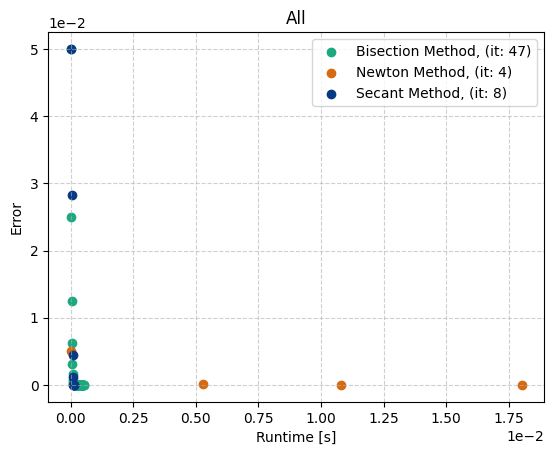

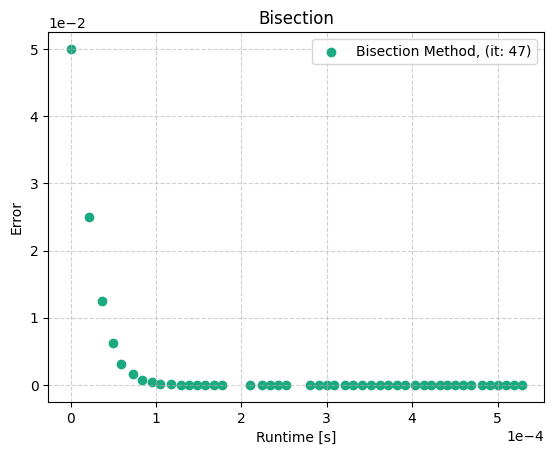

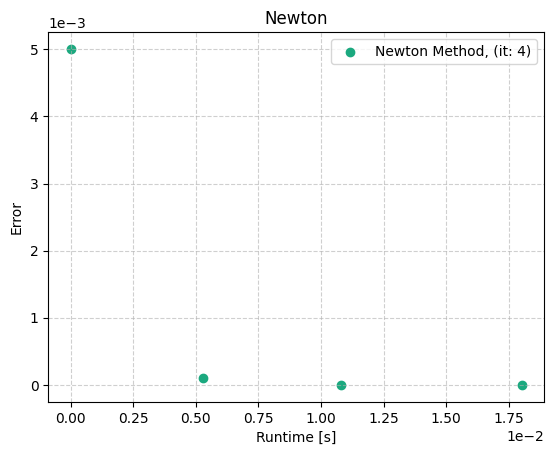

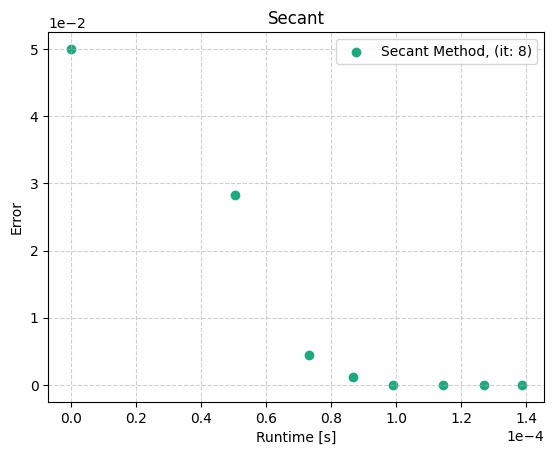

<Axes: title={'center': 'Secant'}, xlabel='Runtime [s]', ylabel='Error'>

In [50]:
_, log_bisec, _ = root_bi_section(func_even, 1.3, 1.4, tolerance=1e-15)
_, log_newt, _ = root_by_newt(func_even, 1.35, tolerance=1e-15)
_, log_sec, _ = root_by_secant(func_even, 1.3, 1.4, tolerance=1e-15)

newt_time = np.array(log_newt['cumulative_time']) - log_newt['cumulative_time'][0]

plt.scatter(log_bisec['cumulative_time'], log_bisec['error'], label=fr'Bisection Method, (it: {len(log_bisec['iteration'])})')
plt.scatter(newt_time, log_newt['error'], label=fr'Newton Method, (it: {len(log_newt['iteration'])})')
plt.scatter(log_sec['cumulative_time'], log_sec['error'], label=fr'Secant Method, (it: {len(log_sec['iteration'])})')
pap.plot_me('All', 'Runtime [s]', 'Error')

plt.scatter(log_bisec['cumulative_time'], log_bisec['error'], label=fr'Bisection Method, (it: {len(log_bisec['iteration'])})')
pap.plot_me('Bisection', 'Runtime [s]', 'Error')

plt.scatter(newt_time, log_newt['error'], label=fr'Newton Method, (it: {len(log_newt['iteration'])})')
pap.plot_me('Newton', 'Runtime [s]', 'Error')

plt.scatter(log_sec['cumulative_time'], log_sec['error'], label=fr'Secant Method, (it: {len(log_sec['iteration'])})')
pap.plot_me('Secant', 'Runtime [s]', 'Error')


<hr>

## Exercise 5: Dependence on Well Depth (optional 3 pt.)
Repeat the analysis for
$$V_0 = 5, 10, 20, 50.$$
Comment on the number of bound states and on the behaviour of the roots with
increasing $V_0$ (location/slope). What happens for $V_0 \to \infty$? Comment on the accuracy
of a root $z$ for a given stopping criterion based on the value of $f(z) (|f (z)| < \epsilon)$.

In [51]:
def print_results(V_0, results):
    roots, iterations, runtimes = results
    methods = ["Secant", "Newton", "Bisection"]

    print(f"\n=== Results for V_0 = {V_0} ===")
    print(f"{'Method':<12} {'Root':<15} {'Iterations':<12} {'Runtime (s)':<12}")
    print("-" * 55)

    for m_idx, method in enumerate(methods):
        for i in range(len(roots[m_idx])):
            print(f"{method:<12} "
                  f"{roots[m_idx][i]:<15.8f} "
                  f"{iterations[m_idx][i]:<12} "
                  f"{runtimes[m_idx][i]:<12.6f}")

In [52]:
V_0_list = [5,10,20,50]

#Collection roots for plotting
all_roots = {
    "Secant": [],
    "Newton": [],
    "Bisection": []
}

for V_0 in V_0_list:
    z_0 = calc_z_0(V_0)
    func_even = z * sp.tan(z) - sp.sqrt(z_0**2 - z**2)
    func_odd = -z / sp.tan(z) - sp.sqrt(z_0**2 - z**2)

    # print(f'For V_0 = {V_0} we expect approximately {int(z_0/np.pi) + 1} bound states.')

    # print('\n=====================\n')

    res = calc_roots(func_even, 0, z_0, 0.02, 1, tolerance=1e-12, max_iterations=5000)
    print_results(V_0, res)

    roots, _, _ = res
    all_roots["Secant"].append(roots[0])
    all_roots["Newton"].append(roots[1])
    all_roots["Bisection"].append(roots[2])


=== Results for V_0 = 5 ===
Method       Root            Iterations   Runtime (s) 
-------------------------------------------------------
Secant       1.38903523      6            0.000192    
Secant       4.14296782      5            0.000109    
Newton       1.38903523      3            0.023695    
Newton       4.14296782      3            0.022788    
Bisection    1.38903523      35           0.000272    
Bisection    4.14296782      35           0.000295    

=== Results for V_0 = 10 ===
Method       Root            Iterations   Runtime (s) 
-------------------------------------------------------
Secant       1.43807632      5            0.000102    
Secant       4.30506973      5            0.000101    
Newton       1.43807632      4            0.029911    
Newton       4.30506973      3            0.022139    
Bisection    1.43807632      35           0.000290    
Bisection    4.30506973      35           0.000274    

=== Results for V_0 = 20 ===
Method       Root            

In [53]:
for V_0 in V_0_list:
    z_0 = calc_z_0(V_0)
    print(f'{z_0:.3f}')
    func_even = z * sp.tan(z) - sp.sqrt(z_0**2 - z**2)
    r_int = find_root_intervalls(func_even, 0, z_0, 0.02, 1, tolerance=1e-4)
    print(len(r_int[0]))


7.684
3
10.867
4
15.369
5
24.300
7


/home/anonymous/Documents/GitHub/Introduction-to-Computational-Physics/Papulator.py:535: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


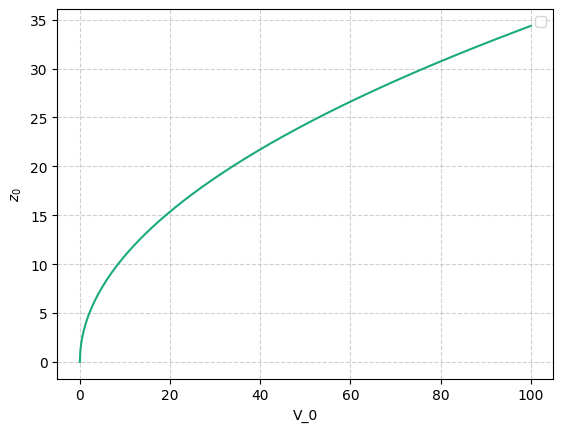

<Axes: xlabel='V_0', ylabel='$z_0$'>

In [57]:
x_space= np.linspace(0, 100, 1000)
plt.plot(x_space, calc_z_0(x_space))
pap.plot_me(xlabel='V_0', ylabel=r'$z_0$')

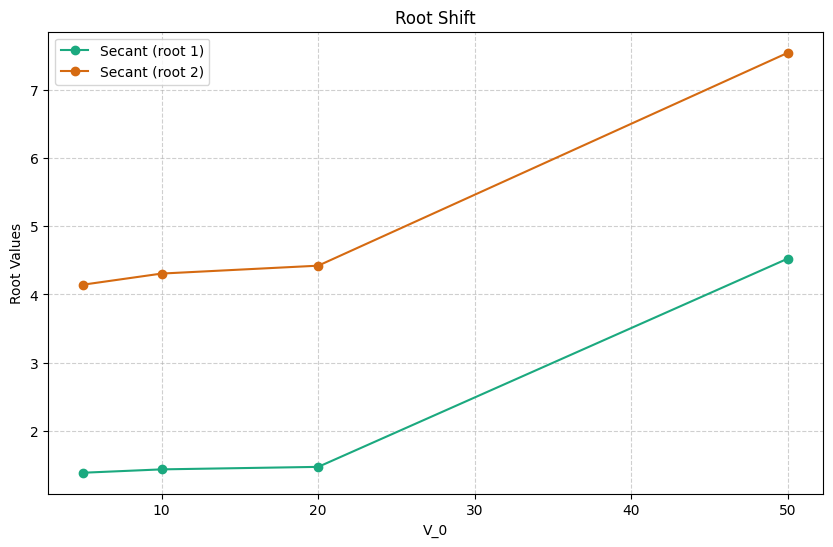

<Axes: title={'center': 'Root Shift'}, xlabel='V_0', ylabel='Root Values'>

In [54]:
plt.figure(figsize=(10, 6))

methods = ["Secant", "Newton", "Bisection"]
#Since the results are all quite the same
methods = ["Secant"]

for m_idx, method in enumerate(methods):
    method_roots = all_roots[method]

    n_roots = min(len(r) for r in method_roots)

    for i in range(n_roots):
        y_vals = [method_roots[j][i] for j in range(len(V_0_list))]

        plt.plot(V_0_list, y_vals,
                 marker='o',
                 linestyle='-',
                 label=f"{method} (root {i+1})")

pap.plot_me('Root Shift', 'V_0', 'Root Values')

<hr>

### Behaviour of the Roots

As $V_0$ increases:

- The interval $(0, z_0)$ becomes larger.
- New roots appear at higher values of $z$.
- Existing roots shift slightly to the right.

The roots tend to align with the asymptotes of $\tan(z)$ and $\cot(z)$.
In particular:
- Even solutions lie near $z \approx n\pi$
- Odd solutions lie near $z \approx (n + \tfrac{1}{2})\pi$

The slope of the root curves decreases for larger $z$, meaning higher-energy
states are less sensitive to changes in $V_0$.

---

### Limit $V_0 \to \infty$

In the limit of an infinitely deep well:
$$V_0 \to \infty \quad \Rightarrow \quad z_0 \to \infty.$$

The transcendental equations simplify because
$$\sqrt{z_0^2 - z^2} \approx z_0,$$
and effectively impose hard boundary conditions.

---

### Accuracy of the Root Criterion

The stopping criterion used is
$$|f(z)| < \varepsilon.$$

However, this does not directly control the error in $z$. Using a first-order
Taylor expansion,
$$f(z + \delta z) \approx f(z) + f'(z)\,\delta z,$$
we obtain
$$\delta z \approx \frac{\varepsilon}{|f'(z)|}.$$

This shows that:
- If $|f'(z)|$ is large, the root is very accurate.
- If $|f'(z)|$ is small (flat region), the error in $z$ can be large even if
  $|f(z)|$ is small.

Therefore, a stopping criterion based only on $|f(z)|$ can be misleading.
A more reliable approach would also monitor:
- the change in $z$ between iterations, or
- use a combined criterion involving both $|f(z)|$ and $|\Delta z|$.

---

### Summary

- The number of bound states increases with $\sqrt{V_0}$.
- Roots shift to higher values and new roots appear as $V_0$ increases.
- In the limit $V_0 \to \infty$, the system reduces to the infinite square well.
- The accuracy of numerical roots depends not only on $|f(z)|$, but also on the
  local slope of the function.